In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**SNAI**

In [6]:
# =============================================================================
# CRI-XAI — Municipal-Level Rank-Graduation Measures per il CRI (#14)
# Implementa ESATTAMENTE le formule dell'Appendix A della relatrice:
#   RGE_CRI = Spearman rank correlation (Ci vs benchmark esterno)
#   RGF_CRI = 1 - sup|F1(y) - F2(y)|  (Kolmogorov-Smirnov tra due gruppi)
#   RGR_CRI = E[Jaccard(R_alpha, R_alpha^(eps))]  (stabilità del top-alpha%)
#
# ATTENZIONE: le scelte operative sotto (benchmark SNAI, gruppi montani,
# parametri perturbazione) sono PROPOSTE da discutere giovedì con Fabio,
# non valori definitivi.
# =============================================================================

import pandas as pd
import numpy as np
from scipy.stats import spearmanr, ks_2samp

# --- Caricamento C_i per tutti i comuni (esportato da R) ---
#PATH_CI = './Materiale/Ci_finale_tutti_comuni_BIS.csv'
###RICORDA CHE STAI USANDO ALEXIA CSV
PATH_CI = './Materiale/Ci_finale_tutti_comuni_BIS_Alexia.csv'
df = pd.read_csv(PATH_CI)
df = df.rename(columns={
    'indice_privacy_simple': 'M_i',
    'indice_pca_norm01': 'P_i',
    'Indice_RF_privacy_norm': 'R_i',
    'Indice_composito_misto': 'C_i',
})
print(f"Comuni caricati: {len(df)}")


# =============================================================================
# RGE_CRI — Spearman tra ranking C_i e benchmark esterno (SNAI)
# =============================================================================
# PROPOSTA: benchmark = classificazione SNAI (Aree Interne), 6 classi ordinate
# A=Polo, B=Polo intercomunale, C=Cintura, D=Intermedio, E=Periferico, F=Ultraperiferico
# Scaricare da: https://www.istat.it/wp-content/uploads/2022/07/20220715_Elenco_Comuni_Classi_di_Aree_Interne.xlsx
PATH_SNAI = './Materiale/Elenco_Comuni_Classi_Aree_Interne.xlsx' #da scaricare

try:
    df_snai = pd.read_excel(PATH_SNAI)
    print("\nColonne SNAI trovate:", df_snai.columns.tolist())

    # Uso il ciclo 2021-2027 (più recente, coerente con l'anno fiscale 2021 usato altrove)
    COLONNA_CODICE_COMUNE_SNAI = 'PROCOM_N'
    COLONNA_CLASSE_SNAI = 'CODICE_Aree_Interne 2021-2027'  # verifica nome esatto dopo il caricamento

    ordine_classi = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6}
    df_snai['classe_numerica'] = df_snai[COLONNA_CLASSE_SNAI].map(ordine_classi)

    n_non_mappati = df_snai['classe_numerica'].isna().sum()
    if n_non_mappati > 0:
        print(f"⚠️ {n_non_mappati} comuni con classe non riconosciuta — valori unici trovati:")
        print(df_snai[df_snai['classe_numerica'].isna()][COLONNA_CLASSE_SNAI].unique())

    df_merged = df.merge(
        df_snai[[COLONNA_CODICE_COMUNE_SNAI, 'classe_numerica']],
        left_on='Codice.comune', right_on=COLONNA_CODICE_COMUNE_SNAI, how='inner'
    )
    print(f"\nComuni con corrispondenza SNAI: {len(df_merged)} su {len(df)}")

    df_merged_validi = df_merged.dropna(subset=['classe_numerica'])
    rge_cri, pval = spearmanr(df_merged_validi['C_i'], df_merged_validi['classe_numerica'])
    print(f"\n✅ RGE_CRI (Spearman C_i vs classificazione SNAI 2021-2027): {rge_cri:.4f} (p-value: {pval:.2e})")
    print("Interpretazione attesa: correlazione POSITIVA (C_i alto ↔ classe periferica alta)")

except FileNotFoundError:
    print(f"\n⚠️ File SNAI non trovato in {PATH_SNAI} — scaricalo dal link sopra e caricalo su Drive")


# =============================================================================
# RGF_CRI — Kolmogorov-Smirnov tra due gruppi territoriali (Dataset ISTAT)
# =============================================================================
PATH_ISTAT_TERR = './Materiale/classificazione comuni montani.xlsx'

try:
    # Carichiamo il file ISTAT delle caratteristiche territoriali con il nome corretto
    df_istat = pd.read_excel(PATH_ISTAT_TERR)

    # Normalizziamo/verifichiamo il codice comune per il merge
    df_istat['Codice.comune'] = df_istat['Codice Comune (alfanumerico)'].astype(str).str.zfill(6)
    df['Codice.comune'] = df['Codice.comune'].astype(str).str.zfill(6)

    df_merged_istat = df.merge(df_istat[['Codice.comune', 'Zona altimetrica']], on='Codice.comune', how='inner')

    # Converte la colonna in formato numerico per sicurezza
    df_merged_istat['Zona altimetrica'] = pd.to_numeric(df_merged_istat['Zona altimetrica'], errors='coerce')

    variabile_interesse = 'C_i'

    # Estrazione dei due gruppi basati sulla classificazione altimetrica ISTAT
    # G1 = Montagna interna o litoranea (1, 2)
    # G2 = Non montani: Collina interna/litoranea e Pianura (3, 4, 5)
    gruppo_1 = df_merged_istat[df_merged_istat['Zona altimetrica'].isin([1, 2])][variabile_interesse].dropna()
    gruppo_2 = df_merged_istat[df_merged_istat['Zona altimetrica'].isin([3, 4, 5])][variabile_interesse].dropna()

    # Esecuzione del test di Kolmogorov-Smirnov a due campioni
    ks_stat, ks_pval = ks_2samp(gruppo_1, gruppo_2)
    rgf_cri = 1 - ks_stat

    print(f"\nRisultati Test Kolmogorov-Smirnov tra Comuni Montani e Non Montani:")
    print(f"Statistica KS: {ks_stat:.4f}")
    print(f"P-value: {ks_pval:.4f}")
    print(f"RGF_CRI (1 - KS statistic): {rgf_cri:.4f}")

except FileNotFoundError:
    print(f"\n⚠️ File delle caratteristiche territoriali ISTAT non trovato in '{PATH_ISTAT_TERR}'. Controlla che il file sia nella stessa cartella dello script.")
except Exception as e:
    print(f"\n⚠️ Si è verificato un errore durante l'elaborazione di RGF_CRI: {e}")

# =============================================================================
# RGR_CRI — Jaccard medio tra top-alpha% originale e perturbato
# =============================================================================
# PROPOSTA: perturbazione ±5% (rumore uniforme moltiplicativo) sugli
# indicatori grezzi di M_i/P_i/R_i, B=1000 repliche, alpha=0.05 (top 5%)
ALPHA = 0.05
EPSILON = 0.05  # ampiezza perturbazione: rumore uniforme in [1-eps, 1+eps]
B_REPLICHE = 1000
RANDOM_STATE = 42

n_top = int(len(df) * ALPHA)
top_originale = set(df.nlargest(n_top, 'C_i')['Codice.comune'])
print(f"\nInsieme R_alpha originale (top {ALPHA:.0%}): {len(top_originale)} comuni")

rng = np.random.default_rng(RANDOM_STATE)
jaccard_scores = []

for b in range(B_REPLICHE):
    # Perturbazione diretta sui pilastri già calcolati (approssimazione pratica,
    # da validare con Fabio: idealmente si perturberebbero gli indicatori
    # grezzi PRIMA di ricalcolare M_i/P_i/R_i in R, ma richiederebbe B rerun
    # completi della pipeline — computazionalmente non fattibile in tempi brevi)
    rumore_M = rng.uniform(1 - EPSILON, 1 + EPSILON, size=len(df))
    rumore_P = rng.uniform(1 - EPSILON, 1 + EPSILON, size=len(df))
    rumore_R = rng.uniform(1 - EPSILON, 1 + EPSILON, size=len(df))

    C_i_perturbato = (
        0.45 * df['M_i'] * rumore_M +
        0.45 * df['P_i'] * rumore_P +
        0.10 * df['R_i'] * rumore_R
    )

    df_temp = df.copy()
    df_temp['C_i_pert'] = C_i_perturbato
    top_perturbato = set(df_temp.nlargest(n_top, 'C_i_pert')['Codice.comune'])

    jaccard = len(top_originale & top_perturbato) / len(top_originale | top_perturbato)
    jaccard_scores.append(jaccard)

rgr_cri = np.mean(jaccard_scores)
print(f"\nRGR_CRI (Jaccard medio su {B_REPLICHE} repliche, ε={EPSILON:.0%}, α={ALPHA:.0%}): {rgr_cri:.4f}")
print(f"Std tra repliche: {np.std(jaccard_scores):.4f}")

print("\n✅ RGR_CRI calcolato con proposta di parametri.")
print("⚠️ NOTA METODOLOGICA per Fabio: questa perturbazione agisce sui pilastri")
print("M_i/P_i/R_i già calcolati, non sugli indicatori grezzi originali — più")
print("veloce ma meno fedele alla definizione. Da discutere se accettabile o")
print("se serve perturbare a monte (richiederebbe rerun multipli della pipeline R).")

Comuni caricati: 7904

Colonne SNAI trovate: ['PROCOM_T', 'PROCOM_N', 'CODICE CATASTALE', 'COD_REG', 'REGIONE', 'COD_PROV', 'SIGLA AUTOM.', "PROVINCIA/CITTA' METROPOLITANA", 'DENOMINAZIONE_COMUNE', 'CODICE_Aree_Interne 2014-2020', 'DESCRIZIONE_Aree_Interne 2014-2020', 'CODICE_Aree_Interne 2021-2027', 'DESCRIZIONE_Aree_Interne 2021-2027', 'PROCOM_Comune di destinazione prevalente \n(AI 2021-27)', 'COMUNE di destinazione prevalente \n(AI 2021-27)', 'CODICE POLO DI DESTINAZIONE PREVALENTE \n(AI 2021-27)']

Comuni con corrispondenza SNAI: 7901 su 7904

✅ RGE_CRI (Spearman C_i vs classificazione SNAI 2021-2027): 0.3962 (p-value: 2.89e-295)
Interpretazione attesa: correlazione POSITIVA (C_i alto ↔ classe periferica alta)


C:\Users\spagnuol\AppData\Local\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")



Risultati Test Kolmogorov-Smirnov tra Comuni Montani e Non Montani:
Statistica KS: 0.3097
P-value: 0.0000
RGF_CRI (1 - KS statistic): 0.6903

Insieme R_alpha originale (top 5%): 395 comuni

RGR_CRI (Jaccard medio su 1000 repliche, ε=5%, α=5%): 0.8139
Std tra repliche: 0.0158

✅ RGR_CRI calcolato con proposta di parametri.
⚠️ NOTA METODOLOGICA per Fabio: questa perturbazione agisce sui pilastri
M_i/P_i/R_i già calcolati, non sugli indicatori grezzi originali — più
veloce ma meno fedele alla definizione. Da discutere se accettabile o
se serve perturbare a monte (richiederebbe rerun multipli della pipeline R).


In [ ]:
print(df_merged_istat.columns.tolist())

['Codice.comune', 'Comune', 'M_i', 'P_i', 'R_i', 'C_i', 'Indice_composito_alt', 'Zona altimetrica']


In [ ]:
df_merged_istat.groupby('Zona altimetrica')['C_i'].agg(['mean', 'median', 'count'])

,mean,median,count
Zona altimetrica,,,
1,0.687551,0.688929,2370
2,0.640788,0.660398,117
3,0.648660,0.655634,2533
4,0.606739,0.611563,785
5,0.603891,0.606174,2099


**IVSM**

PROVE ROBUSTEZZA

Risultati del ciclo sui pesi:
 w_R  w_M_e_w_P (ciascuno)  Spearman_vs_originale  Overlap_top20
0.00                  0.50               0.999893             20
0.02                  0.49               0.999928             20
0.04                  0.48               0.999957             20
0.06                  0.47               0.999980             20
0.08                  0.46               0.999994             20
0.10                  0.45               1.000000             20
0.12                  0.44               0.999994             20
0.14                  0.43               0.999976             19
0.16                  0.42               0.999945             19
0.18                  0.41               0.999898             19
0.20                  0.40               0.999834             19
0.22                  0.39               0.999749             19
0.24                  0.38               0.999640             19
0.26                  0.37               0.999503           

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


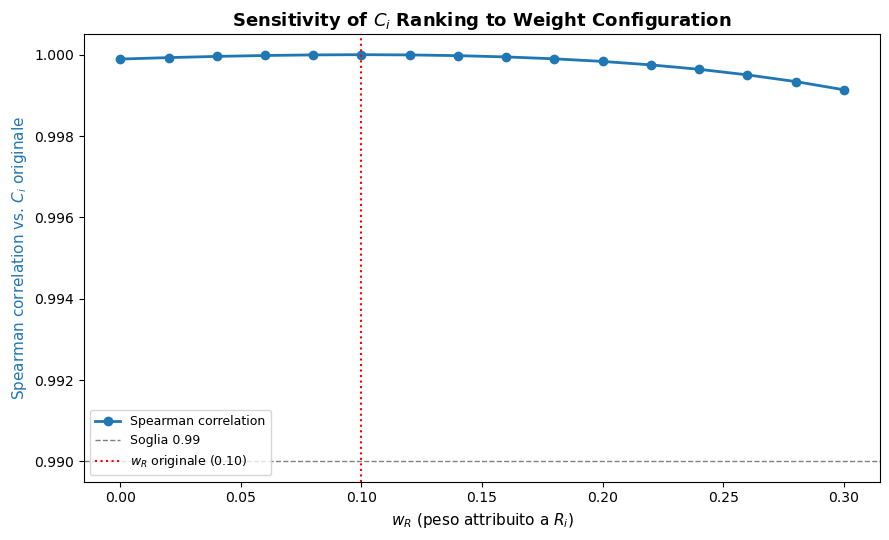


✅ Grafico salvato (PDF + EPS)


In [7]:
# =============================================================================
# CRI-XAI — Ciclo sistematico sui pesi di C_i (estensione di RGR_CRI)
# Raccomandato da OECD (2008) Handbook on Composite Indicators — già citato
# nel paper — come pratica standard per l'analisi di sensibilità sui pesi.
#
# Invece di confrontare solo 2 combinazioni (0.45/0.45/0.10 vs 0.40/0.40/0.20),
# facciamo variare w_R sistematicamente e guardiamo come cambia il ranking.
# =============================================================================

import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

PATH_CI = './Materiale/Ci_finale_tutti_comuni_BIS_Alexia.csv'
df = pd.read_csv(PATH_CI)
df = df.rename(columns={
    'indice_privacy_simple': 'M_i',
    'indice_pca_norm01': 'P_i',
    'Indice_RF_privacy_norm': 'R_i',
})

# --- C_i di riferimento con i pesi originali ---
W_R_ORIGINALE = 0.10
C_i_originale = 0.45 * df['M_i'] + 0.45 * df['P_i'] + 0.10 * df['R_i']

# --- Ciclo: w_R varia da 0.00 a 0.30, w_M e w_P si dividono il resto a metà ---
valori_w_R = np.arange(0.00, 0.31, 0.02)  # 0%, 2%, 4%, ..., 30%
correlazioni = []
overlap_top20 = []

top20_originale = set(
    pd.DataFrame({'Codice.comune': df['Codice.comune'], 'C_i': C_i_originale})
    .nlargest(20, 'C_i')['Codice.comune']
)

for w_R in valori_w_R:
    w_rimanente = (1 - w_R) / 2  # M_i e P_i restano sempre uguali tra loro
    C_i_test = w_rimanente * df['M_i'] + w_rimanente * df['P_i'] + w_R * df['R_i']

    corr, _ = spearmanr(C_i_originale, C_i_test)
    correlazioni.append(corr)

    top20_test = set(
        pd.DataFrame({'Codice.comune': df['Codice.comune'], 'C_i': C_i_test})
        .nlargest(20, 'C_i')['Codice.comune']
    )
    overlap = len(top20_originale & top20_test)
    overlap_top20.append(overlap)

risultati = pd.DataFrame({
    'w_R': valori_w_R,
    'w_M_e_w_P (ciascuno)': (1 - valori_w_R) / 2,
    'Spearman_vs_originale': correlazioni,
    'Overlap_top20': overlap_top20,
})
print("Risultati del ciclo sui pesi:")
print(risultati.to_string(index=False))

soglia_stabile = risultati[risultati['Spearman_vs_originale'] >= 0.99]
print(f"\n✅ Il ranking resta stabile (Spearman ≥ 0.99) per w_R tra "
      f"{soglia_stabile['w_R'].min():.2f} e {soglia_stabile['w_R'].max():.2f}")

# --- Grafico ---
fig, ax1 = plt.subplots(figsize=(9, 5.5))
ax1.plot(valori_w_R, correlazioni, color='#1f77b4', marker='o', linewidth=2,
         label='Spearman correlation')
ax1.axhline(0.99, color='gray', linestyle='--', linewidth=1, label='Soglia 0.99')
ax1.set_xlabel('$w_R$ (peso attribuito a $R_i$)', fontsize=11)
ax1.set_ylabel('Spearman correlation vs. $C_i$ originale', fontsize=11, color='#1f77b4')
ax1.set_title('Sensitivity of $C_i$ Ranking to Weight Configuration', fontsize=13, fontweight='bold')
ax1.axvline(0.10, color='red', linestyle=':', linewidth=1.5, label='$w_R$ originale (0.10)')
ax1.legend(loc='lower left', fontsize=9)
plt.tight_layout()
plt.savefig('./Materiale/weight_sensitivity_sweep.pdf',
            dpi=300, bbox_inches='tight')
plt.savefig('./Materiale/weight_sensitivity_sweep.eps',
            dpi=300, bbox_inches='tight', format='eps')
plt.show()
print("\n✅ Grafico salvato (PDF + EPS)")

proseguiamo per vedere tutti i risultati

Risultati del ciclo sui pesi:
 w_R  w_M_e_w_P (ciascuno)  Spearman_vs_originale  Overlap_top20
0.00                 0.500               0.999893             20
0.05                 0.475               0.999969             20
0.10                 0.450               1.000000             20
0.15                 0.425               0.999962             19
0.20                 0.400               0.999834             19
0.25                 0.375               0.999575             19
0.30                 0.350               0.999137             19
0.35                 0.325               0.998440             19
0.40                 0.300               0.997376             18
0.45                 0.275               0.995766             18
0.50                 0.250               0.993364             17
0.55                 0.225               0.989699             17
0.60                 0.200               0.984076             16
0.65                 0.175               0.975214           

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


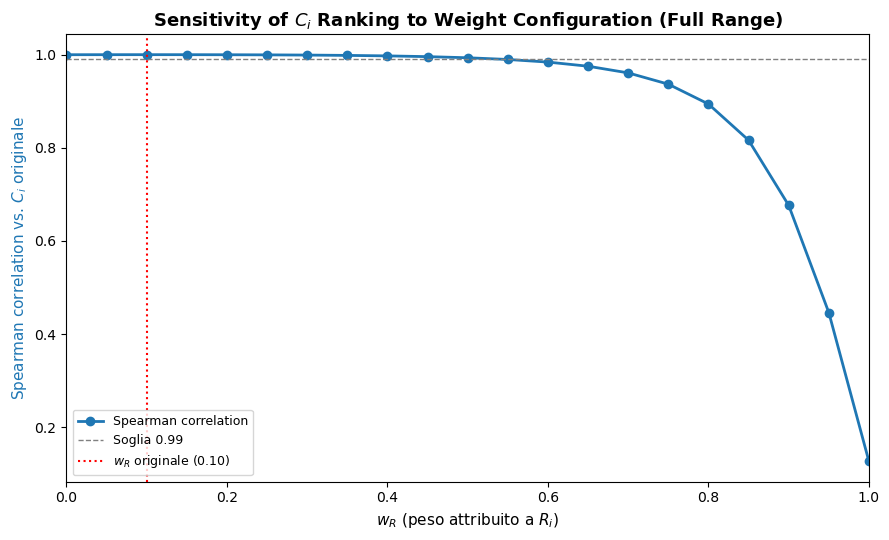


✅ Grafico salvato (PDF + EPS)


In [9]:
# =============================================================================
# CRI-XAI — Ciclo sistematico sui pesi di C_i (estensione di RGR_CRI)
# Raccomandato da OECD (2008) Handbook on Composite Indicators — già citato
# nel paper — come pratica standard per l'analisi di sensibilità sui pesi.
#
# Invece di confrontare solo 2 combinazioni (0.45/0.45/0.10 vs 0.40/0.40/0.20),
# facciamo variare w_R sistematicamente e guardiamo come cambia il ranking.
# =============================================================================

import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

PATH_CI = './Materiale/Ci_finale_tutti_comuni_BIS_Alexia.csv'
df = pd.read_csv(PATH_CI)
df = df.rename(columns={
    'indice_privacy_simple': 'M_i',
    'indice_pca_norm01': 'P_i',
    'Indice_RF_privacy_norm': 'R_i',
})

# --- C_i di riferimento con i pesi originali ---
W_R_ORIGINALE = 0.10
C_i_originale = 0.45 * df['M_i'] + 0.45 * df['P_i'] + 0.10 * df['R_i']

# --- Ciclo: w_R varia da 0.00 a 1.00, w_M e w_P si dividono il resto a metà ---
valori_w_R = np.arange(0.00, 1.01, 0.05)  # 0%, 5%, 10%, ..., 100%
correlazioni = []
overlap_top20 = []

top20_originale = set(
    pd.DataFrame({'Codice.comune': df['Codice.comune'], 'C_i': C_i_originale})
    .nlargest(20, 'C_i')['Codice.comune']
)

for w_R in valori_w_R:
    w_rimanente = (1 - w_R) / 2  # M_i e P_i restano sempre uguali tra loro
    C_i_test = w_rimanente * df['M_i'] + w_rimanente * df['P_i'] + w_R * df['R_i']

    corr, _ = spearmanr(C_i_originale, C_i_test)
    correlazioni.append(corr)

    top20_test = set(
        pd.DataFrame({'Codice.comune': df['Codice.comune'], 'C_i': C_i_test})
        .nlargest(20, 'C_i')['Codice.comune']
    )
    overlap = len(top20_originale & top20_test)
    overlap_top20.append(overlap)

risultati = pd.DataFrame({
    'w_R': valori_w_R,
    'w_M_e_w_P (ciascuno)': (1 - valori_w_R) / 2,
    'Spearman_vs_originale': correlazioni,
    'Overlap_top20': overlap_top20,
})
print("Risultati del ciclo sui pesi:")
print(risultati.to_string(index=False))

soglia_stabile = risultati[risultati['Spearman_vs_originale'] >= 0.99]
print(f"\n✅ Il ranking resta stabile (Spearman ≥ 0.99) per w_R tra "
      f"{soglia_stabile['w_R'].min():.2f} e {soglia_stabile['w_R'].max():.2f}")

# --- Grafico ---
fig, ax1 = plt.subplots(figsize=(9, 5.5))
ax1.plot(valori_w_R, correlazioni, color='#1f77b4', marker='o', linewidth=2,
         label='Spearman correlation')
ax1.axhline(0.99, color='gray', linestyle='--', linewidth=1, label='Soglia 0.99')
ax1.set_xlabel('$w_R$ (peso attribuito a $R_i$)', fontsize=11)
ax1.set_ylabel('Spearman correlation vs. $C_i$ originale', fontsize=11, color='#1f77b4')
ax1.set_title('Sensitivity of $C_i$ Ranking to Weight Configuration (Full Range)', fontsize=13, fontweight='bold')
ax1.set_xlim(0, 1.0)
ax1.axvline(0.10, color='red', linestyle=':', linewidth=1.5, label='$w_R$ originale (0.10)')
ax1.legend(loc='lower left', fontsize=9)
plt.tight_layout()
plt.savefig('./Materiale/weight_sensitivity_sweep.pdf',
            dpi=300, bbox_inches='tight')
plt.savefig('./Materiale/weight_sensitivity_sweep.eps',
            dpi=300, bbox_inches='tight', format='eps')
plt.show()
print("\n✅ Grafico salvato (PDF + EPS)")
#prova x fabio top50